<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Project_3_Credit_Card_Fraud_Detection_using_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection using Unsupervised Learning
This project implements Isolation Forest, One-Class SVM and Autoencoder models for fraud detection using unsupervised learning.

# 1. Install & Import Libraries

In [1]:
!pip install scikit-learn tensorflow pandas matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.metrics import precision_recall_curve, roc_auc_score, auc
from sklearn.cluster import KMeans, DBSCAN
from sklearn.cluster import DBSCAN
import tensorflow as tf
from tensorflow.keras import layers, models


# 2. Upload and Extract Dataset

In [2]:
from google.colab import files
uploaded = files.upload()  # Upload creditcard.csv or zip
import zipfile, io
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(io.BytesIO(uploaded[filename])) as z:
            z.extractall()
df = pd.read_csv('creditcard.csv')
df.head()

Saving creditcard.zip to creditcard (1).zip


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Loading the Dataset
import pandas as pd

df = pd.read_csv('creditcard.csv')

In [4]:
# Preprocess
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

labels = df['Class']
X = df.drop(columns=['Class'])

# 3. Preprocessing

In [5]:
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])
labels = df['Class']
X = df.drop(columns=['Class'])
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244964
1,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342475
2,-1.996562,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.160686
3,-1.996562,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.140534
4,-1.996541,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073403


# 4. Isolation Forest

In [6]:
iso = IsolationForest(contamination=0.001, random_state=42)
iso.fit(X)
iso_pred = iso.predict(X)
iso_pred = np.where(iso_pred == -1, 1, 0)

# 5. One-Class SVM

In [7]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)
ocsvm = OneClassSVM(nu=0.001, kernel='rbf', gamma='scale')
ocsvm.fit(X_pca)
svm_pred = ocsvm.predict(X_pca)
svm_pred = np.where(svm_pred == -1, 1, 0)

# 6. Autoencoder

In [8]:
X_train = X[labels == 0]
input_dim = X_train.shape[1]
model = models.Sequential([
    layers.Dense(16, activation='relu', input_shape=(input_dim,)),
    layers.Dense(8, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, X_train, epochs=5, batch_size=256, verbose=1)
recon = model.predict(X)
mse = np.mean(np.power(X - recon, 2), axis=1)
threshold = np.percentile(mse, 99.9)
ae_pred = (mse > threshold).astype(int)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.6111
Epoch 2/5
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3623
Epoch 3/5
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3361
Epoch 4/5
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3241
Epoch 5/5
1111/1111 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.3136
8901/8901 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step


# 7. Evaluation

In [9]:
def evaluate(y_true, y_scores, name):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)
    roc = roc_auc_score(y_true, y_scores)
    print(f"{name} PR-AUC: {pr_auc:.4f}, ROC-AUC: {roc:.4f}")
    return precision, recall

p1, r1 = evaluate(labels, iso_pred, 'Isolation Forest')
p2, r2 = evaluate(labels, svm_pred, 'OC-SVM')
p3, r3 = evaluate(labels, ae_pred, 'Autoencoder')

Isolation Forest PR-AUC: 0.2307, ROC-AUC: 0.5840
OC-SVM PR-AUC: 0.1203, ROC-AUC: 0.5729
Autoencoder PR-AUC: 0.4910, ROC-AUC: 0.6797


# 8. Precision-Recall Curve

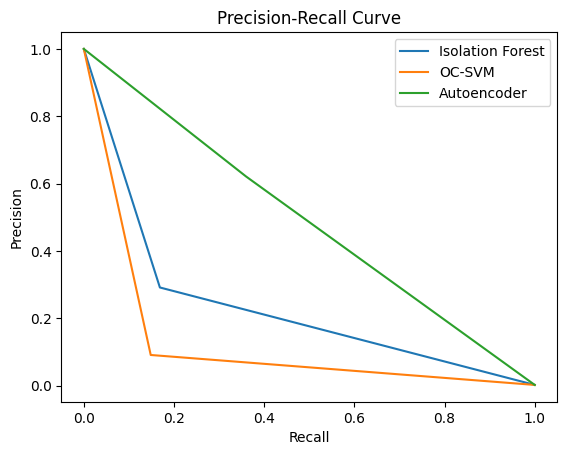

In [10]:
plt.plot(r1, p1, label='Isolation Forest')
plt.plot(r2, p2, label='OC-SVM')
plt.plot(r3, p3, label='Autoencoder')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.title('Precision-Recall Curve')
plt.show()

# 9. K-Means Clustering

In [11]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)
print(pd.crosstab(labels, clusters))

col_0       0      1
Class               
0      268503  15812
1         254    238


# 10. DBSCAN

In [12]:
X_sample = X.sample(n=10000, random_state=42)

db = DBSCAN(eps=2.5, min_samples=10, n_jobs=-1)
db_labels = db.fit_predict(X_sample)

print(pd.Series(db_labels).value_counts())

 1     4707
-1     3332
 0      404
 4      386
 3      295
 2      272
 12     118
 5      106
 7       89
 10      82
 6       70
 9       28
 8       23
 16      15
 14      15
 13      14
 11      12
 17      11
 18      11
 15      10
Name: count, dtype: int64


In [13]:
for eps in [2.5, 3, 4, 5]:
    db = DBSCAN(eps=eps, min_samples=10, n_jobs=-1)
    labels_db = db.fit_predict(X_sample)
    print(f"eps={eps}")
    print(pd.Series(labels_db).value_counts())
    print("-"*40)

eps=2.5
 1     4707
-1     3332
 0      404
 4      386
 3      295
 2      272
 12     118
 5      106
 7       89
 10      82
 6       70
 9       28
 8       23
 16      15
 14      15
 13      14
 11      12
 17      11
 18      11
 15      10
Name: count, dtype: int64
----------------------------------------
eps=3
 0    7232
-1    1985
 1     402
 2     381
Name: count, dtype: int64
----------------------------------------
eps=4
 0    9250
-1     750
Name: count, dtype: int64
----------------------------------------
eps=5
 0    9644
-1     356
Name: count, dtype: int64
----------------------------------------
